In [1]:
import pandas as pd 
import numpy as np

In [ ]:
# fixing the random ness
np.random.seed(42)

In [3]:
# creating empty list 
cycles = []
time = []
voltage = []
current = []
temperature = []

In [4]:
 # simulate multi- row per cycle dataset 
for cycle in range(1, 101): # 100 cycles
    for t in range(0, 50): # 50 time points per cycle
        cycles.append(cycle)
        time.append(t)

        # simulate degradation
        base_voltage = 4.2 - 0.01* cycle
        voltage.append(base_voltage - 0.02 * t + np.random.normal(0.01))
        current.append(-1.5)
        temperature.append(25 + 0.02 * cycle + np.random.normal(0.02))

In [5]:
# Convert Lists to DataFrame -  tillnow we only had empty list now we will convert it to dataframe
df_large = pd.DataFrame({
    "cycle": cycles,
    "time": time,
     "voltage": voltage,
    "current": current,
    "temperature": temperature
})


In [9]:
df_large.head()


,cycle,time,voltage,current,temperature
0,1,0,4.696714,-1.5,24.901736
1,1,1,4.827689,-1.5,26.563030
2,1,2,3.925847,-1.5,24.805863
3,1,3,5.719213,-1.5,25.807435
4,1,4,3.650526,-1.5,25.582560


In [10]:
df_large.shape

(5000, 5)

In [11]:
# lets group all cycle 1 points so that np can ready it as one block 
grouped = df_large.groupby("cycle")

In [17]:
#lets check - so get_group(number) will show you the head of that group values you can change it to 1,2,3 etc
grouped.get_group(1).head()

,cycle,time,voltage,current,temperature
0,1,0,4.696714,-1.5,24.901736
1,1,1,4.827689,-1.5,26.563030
2,1,2,3.925847,-1.5,24.805863
3,1,3,5.719213,-1.5,25.807435
4,1,4,3.650526,-1.5,25.582560


In [ ]:
min_voltage = grouped["voltage"].min() # we created a table in that in grouped table select voltage column and show me minimum values
min_voltage.head()

cycle
1    0.840255
2    2.162517
3    0.318733
4    1.226104
5    1.672558
Name: voltage, dtype: float64

In [19]:
# Inside each cycle:Temperature fluctuates slightly.We want one representative value per cycle.So we calculate mean.
avg_temp = grouped["temperature"].mean()
avg_temp.head()

cycle
1    24.967983
2    25.200062
3    25.080846
4    25.186130
5    25.020375
Name: temperature, dtype: float64

In [ ]:
voltage_slope = grouped["voltage"].apply( # .apply is dataframe function like for this data frame do this calculation
    lambda x: (x.iloc[-1] - x.iloc[0]) / len(x) # lamda x is like short defined function when you dont want to write a def its short method
)

In [22]:
# now lets combine these features in to big data frame 
df_cycle_features = pd.DataFrame({
    "cycle": min_voltage.index,
    "min_voltage": min_voltage.values,
    "avg_temperature": avg_temp.values,
    "voltage_slope": voltage_slope.values
})
df_cycle_features.head()

,cycle,min_voltage,avg_temperature,voltage_slope
0,1,0.840255,24.967983,-0.029432
1,2,2.162517,25.200062,0.009872
2,3,0.318733,25.080846,-0.010499
3,4,1.226104,25.186130,-0.005311
4,5,1.672558,25.020375,-0.005224


In [23]:
df_cycle_features.shape

(100, 4)

In [24]:
import matplotlib.pyplot as plt

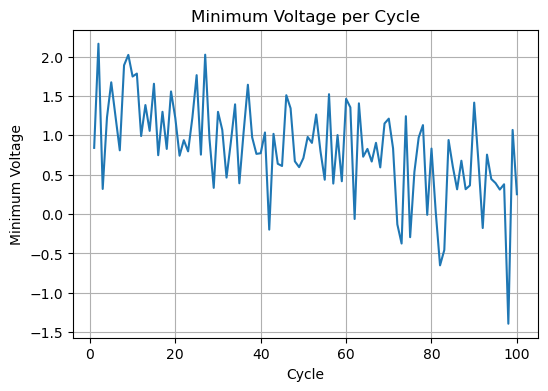

In [25]:
plt.figure(figsize=(6,4))

plt.plot(df_cycle_features["cycle"], 
         df_cycle_features["min_voltage"])

plt.xlabel("Cycle")
plt.ylabel("Minimum Voltage")
plt.title("Minimum Voltage per Cycle")
plt.grid(True)

plt.show()

In [26]:
df_cycle_features.to_csv(
    "../../data/week3_day1_cycle_features.csv",
    index=False
)